<a href="https://colab.research.google.com/github/Manuel-rojas18/Talleres-POO/blob/main/Gradient_Boosting_Visual_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://ai.studio/apps/c2688896-3b1e-473f-8e67-f966a51b5222

import { DataPoint, ComparisonModelResult, TreeNode } from '../types';
import { buildRegressionTree, predictTree, Sample } from './decisionTree';
import { computeR2 } from './gradientBoosting';

export function trainDecisionTreeModel(
  trainPoints: DataPoint[],
  testPoints: DataPoint[],
  gridX: number[],
  maxDepth: number = 6
): ComparisonModelResult {
  const samples: Sample[] = trainPoints.map((p) => ({
    features: [p.x],
    target: p.y,
  }));

  const tree = buildRegressionTree(samples, maxDepth, 2, 0.0);

  const trainPreds = trainPoints.map((p) => predictTree(tree, [p.x]));
  const testPreds = testPoints.map((p) => predictTree(tree, [p.x]));
  const gridPreds = gridX.map((x) => predictTree(tree, [x]));

  const trainMse =
    trainPoints.reduce((acc, p, i) => acc + Math.pow(p.y - trainPreds[i], 2), 0) /
    (trainPoints.length || 1);
  const testMse =
    testPoints.reduce((acc, p, i) => acc + Math.pow(p.y - testPreds[i], 2), 0) /
    (testPoints.length || 1);

  const trainR2 = computeR2(
    trainPoints.map((p) => p.y),
    trainPreds
  );
  const testR2 = computeR2(
    testPoints.map((p) => p.y),
    testPreds
  );

  return {
    name: 'Árbol de Regresión Individual',
    type: 'tree',
    predictions: trainPreds,
    gridPredictions: gridPreds,
    trainMse,
    testMse,
    trainR2,
    testR2,
    description:
      'Un único árbol divide el espacio en cajas rectangulares de forma codiciosa (greedy). Si es muy profundo memoriza el ruido (alto sobreajuste / varianza); si es muy poco profundo, no captura la forma (sesgo).',
    keyCharacteristic: 'Alto sesgo si es bajo, o altísima varianza si es profundo.',
    biasVarianceDiagnosis: 'Varianza alta y frontera de decisión en saltos abruptos.',
  };
}

export function trainRandomForestModel(
  trainPoints: DataPoint[],
  testPoints: DataPoint[],
  gridX: number[],
  numTrees: number = 25,
  maxDepth: number = 5
): ComparisonModelResult {
  const n = trainPoints.length;
  const trees: TreeNode[] = [];

  let seed = 888;
  function random(): number {
    seed = (seed * 9301 + 49297) % 233280;
    return seed / 233280;
  }

  // Train independent trees on bootstrap samples (Bagging)
  for (let b = 0; b < numTrees; b++) {
    const bootstrapSamples: Sample[] = [];
    for (let i = 0; i < n; i++) {
      const idx = Math.floor(random() * n);
      bootstrapSamples.push({
        features: [trainPoints[idx].x],
        target: trainPoints[idx].y,
      });
    }

    const tree = buildRegressionTree(bootstrapSamples, maxDepth, 2, 0.0);
    trees.push(tree);
  }

  // Predict by averaging predictions of all B trees
  const predictForest = (x: number) => {
    const sum = trees.reduce((acc, t) => acc + predictTree(t, [x]), 0);
    return sum / (trees.length || 1);
  };

  const trainPreds = trainPoints.map((p) => predictForest(p.x));
  const testPreds = testPoints.map((p) => predictForest(p.x));
  const gridPreds = gridX.map((x) => predictForest(x));

  const trainMse =
    trainPoints.reduce((acc, p, i) => acc + Math.pow(p.y - trainPreds[i], 2), 0) /
    (trainPoints.length || 1);
  const testMse =
    testPoints.reduce((acc, p, i) => acc + Math.pow(p.y - testPreds[i], 2), 0) /
    (testPoints.length || 1);

  const trainR2 = computeR2(
    trainPoints.map((p) => p.y),
    trainPreds
  );
  const testR2 = computeR2(
    testPoints.map((p) => p.y),
    testPreds
  );

  return {
    name: 'Bosque Aleatorio (Random Forest - Bagging)',
    type: 'forest',
    predictions: trainPreds,
    gridPredictions: gridPreds,
    trainMse,
    testMse,
    trainR2,
    testR2,
    description:
      'Entrena múltiples árboles profundos en paralelo sobre subconjuntos bootstrap y promedia sus predicciones. Su objetivo principal es REDUCIR LA VARIANZA sin aumentar el sesgo.',
    keyCharacteristic: 'Paralelo, promediado de árboles independientes.',
    biasVarianceDiagnosis: 'Excelente reducción de varianza. Menos sensible a sobreajuste.',
  };
}

export function formatBoostingComparison(
  gridPreds: number[],
  trainPreds: number[],
  trainPoints: DataPoint[],
  testPoints: DataPoint[],
  testPreds: number[]
): ComparisonModelResult {
  const trainMse =
    trainPoints.reduce((acc, p, i) => acc + Math.pow(p.y - trainPreds[i], 2), 0) /
    (trainPoints.length || 1);
  const testMse =
    testPoints.reduce((acc, p, i) => acc + Math.pow(p.y - testPreds[i], 2), 0) /
    (testPoints.length || 1);

  const trainR2 = computeR2(
    trainPoints.map((p) => p.y),
    trainPreds
  );
  const testR2 = computeR2(
    testPoints.map((p) => p.y),
    testPreds
  );

  return {
    name: 'Gradient Boosting (Boosting Secuencial)',
    type: 'boosting',
    predictions: trainPreds,
    gridPredictions: gridPreds,
    trainMse,
    testMse,
    trainR2,
    testR2,
    description:
      'Entrena árboles poco profundos SECUENCIALMENTE, cada uno corrigiendo los errores residuales del ensamble anterior con encogimiento (learning rate). Reduce SESGO Y VARIANZA de manera armónica.',
    keyCharacteristic: 'Secuencial, optimización de gradiente sobre residuos.',
    biasVarianceDiagnosis: 'Mínimo sesgo y control fino de varianza mediante tasa de aprendizaje.',
  };
}


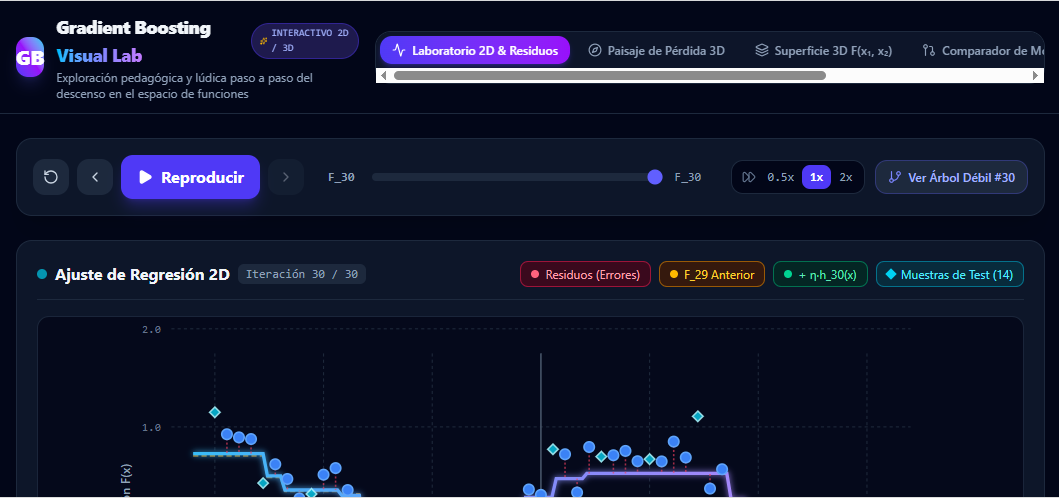

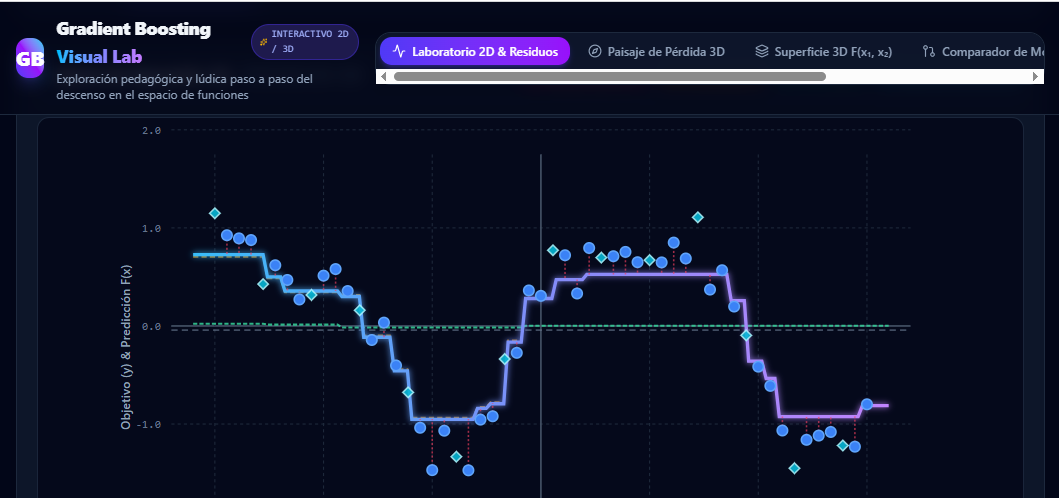

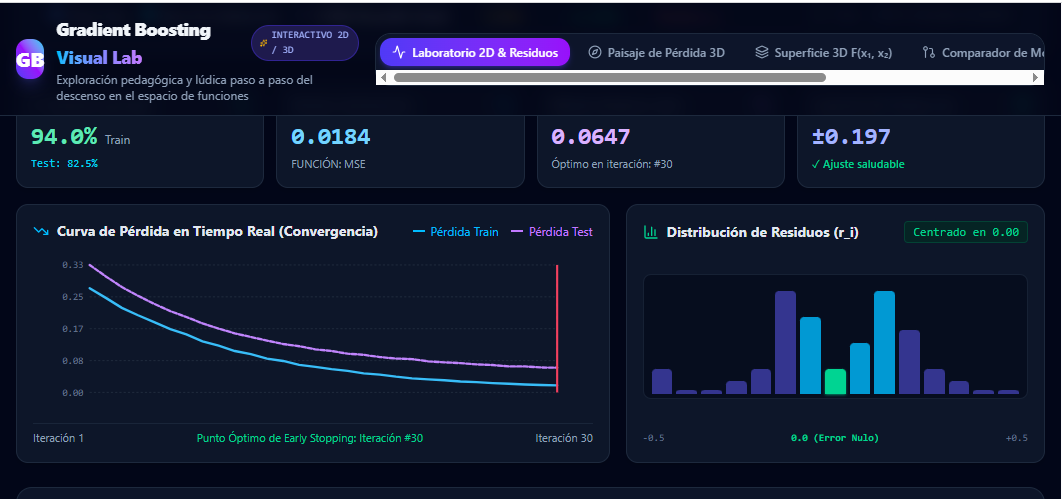

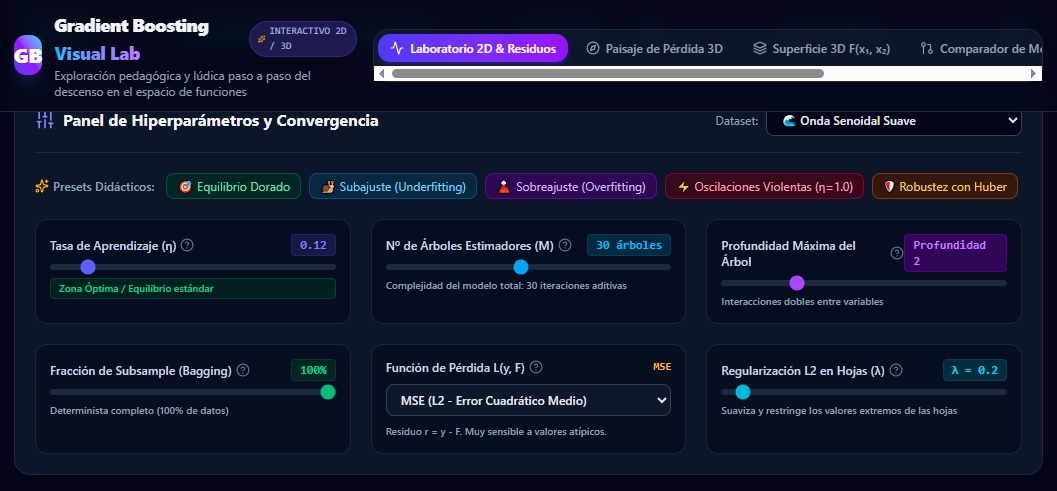